In [1]:
import pandas as pd

# Load the datasets (skiprows because headings are on the second row)
df_fahrenheit = pd.read_excel('reviews_Fahrenheit_Coffee_1000_reviews.xlsx',skiprows=2)
df_dineen     = pd.read_excel('reviews_Dineen_Coffee_Co_1000_reviews.xlsx',skiprows=2)
df_landwer    = pd.read_excel('reviews_Cafe_Landwer_1000_reviews.xlsx',skiprows=2)


#combine all 3 review datasets into 1
df = pd.concat([df_fahrenheit, df_dineen, df_landwer], ignore_index=True)
df['Restaurant Name'] = df['Restaurant Name'].replace('Results', 'Dineen Coffee Co.')
print(f"Total reviews loaded: {len(df)}")
print(df['Restaurant Name'].value_counts())

Total reviews loaded: 3000
Restaurant Name
Fahrenheit Coffee    1000
Dineen Coffee Co.    1000
Cafe Landwer         1000
Name: count, dtype: int64


In [2]:
#Preprocessing the reviews

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#used to reduce words to their stems 
lemmatizer = WordNetLemmatizer()

#take out the words that just add noise
stop_words = set(stopwords.words('english'))




def clean_text_v3(text):
    if not isinstance(text, str) or text.strip() == '':
        return None
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'/', ' ', text) 
    text = re.sub(r'[^a-z0-9\s\'\-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize, remove stopwords, then lemmatize
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    cleaned = ' '.join(tokens)
    return cleaned if len(cleaned) > 20 else None





In [3]:
#Looks like all the reviews have tags where reviewers rate the Food, Service, and Atmosphere. 
#It may be best to extract them into separate columns so that the topic model focuses specifically on the written reviews
import re

def extract_google_tags(text):
    if not isinstance(text, str):
        return {}
    
    result = {}
    text_lower = text.lower()
    
    for field in ['food', 'service', 'atmosphere']:
        match = re.search(rf'{field}:\s*(\d)', text_lower)
        if match:
            result[f'tag_{field}_rating'] = int(match.group(1))
    
    price_match = re.search(r'price per person\s*\$?([\d,–\-]+)', text_lower)
    if price_match:
        result['tag_price_per_person'] = price_match.group(1).strip()
    
    order_match = re.search(r'order type\s*(dine in|takeout|delivery)', text_lower)
    if order_match:
        result['tag_order_type'] = order_match.group(1).strip()
    
    meal_match = re.search(r'meal type\s*(\w+)', text_lower)
    if meal_match:
        result['tag_meal_type'] = meal_match.group(1).strip()
    
    dishes_match = re.search(r'recommended dishes\s*([^\n]+)', text, re.IGNORECASE)
    if dishes_match:
        result['tag_recommended_dishes'] = dishes_match.group(1).strip()
    
    if 'difficult to find parking' in text_lower:
        result['tag_parking'] = 'difficult'
    elif 'easy to find parking' in text_lower:
        result['tag_parking'] = 'easy'
    elif 'free' in text_lower and 'parking' in text_lower:
        result['tag_parking'] = 'free'
    
    if 'wheelchair' in text_lower:
        result['tag_wheelchair'] = 'yes' if any(
            w in text_lower for w in ['yes', 'friendly', 'accessible']
        ) else 'no'
    
    return result

def remove_google_tags(text):
    if not isinstance(text, str):
        return text
    
    cutoff_phrases = [
        'order type', 'meal type', 'price per person',
        'food:', 'service:', 'atmosphere:',
        'recommended dishes', 'parking space',
        'parking options', 'wheelchair',
        'dine in', 'takeout', 'delivery'
    ]
    
    text_lower = text.lower()
    cutoff_idx = len(text)
    for phrase in cutoff_phrases:
        idx = text_lower.find(phrase)
        if idx != -1 and idx < cutoff_idx:
            cutoff_idx = idx
    
    return text[:cutoff_idx].strip()

# Step 1 — extract tags into new columns
tags_df = df['Review Text'].apply(extract_google_tags).apply(pd.Series)
df = pd.concat([df, tags_df], axis=1)

# Step 2 — create clean review text column with tags stripped
df['Review Text Clean'] = df['Review Text'].apply(remove_google_tags)

#Step 3: Lemmatization and stopword removal of clean review
df['Review Text Clean'] = df['Review Text Clean'].apply(clean_text_v3)

# Verify both worked
print("Tag columns extracted:")
print(df[['tag_food_rating', 'tag_service_rating', 'tag_atmosphere_rating',
          'tag_price_per_person', 'tag_order_type', 'tag_meal_type']].head(10))

print("\nTag coverage:")
tag_cols = [c for c in df.columns if c.startswith('tag_')]
print(df[tag_cols].notna().sum().sort_values(ascending=False))




Tag columns extracted:
   tag_food_rating  tag_service_rating  tag_atmosphere_rating  \
0              5.0                 4.0                    4.0   
1              4.0                 4.0                    NaN   
2              5.0                 5.0                    5.0   
3              5.0                 5.0                    5.0   
4              5.0                 5.0                    5.0   
5              5.0                 5.0                    5.0   
6              5.0                 5.0                    5.0   
7              4.0                 4.0                    3.0   
8              NaN                 NaN                    4.0   
9              5.0                 5.0                    5.0   

  tag_price_per_person tag_order_type tag_meal_type  
0                  NaN            NaN           NaN  
1                 1–10            NaN           NaN  
2                  NaN            NaN           NaN  
3                  NaN        dine in        

In [4]:
print("\nOriginal Review:")
print(df['Review Text'].dropna().iloc[0])
print("\nSample cleaned review:")
print(df['Review Text Clean'].dropna().iloc[0])


Original Review:
Very high quality coffee that makes you think about what the other places are serving. But some of the baristas can be rude/edgy
Food: 5
Service: 4
Atmosphere: 4

Sample cleaned review:
high quality coffee make think place serving baristas rude edgy


In [5]:
df.head()

,Review ID,Restaurant Name,Rating,Review Text,Review Date,Author Name,Owner Replied?,Owner Response,Response Date,Review Link,tag_food_rating,tag_service_rating,tag_atmosphere_rating,tag_price_per_person,tag_order_type,tag_meal_type,tag_recommended_dishes,tag_parking,tag_wheelchair,Review Text Clean
0,ChdDSUhNMG9nS0VJQ0FnSUNCZ3NIYmpBRRAB,Fahrenheit Coffee,4 ★★★★☆,Very high quality coffee that makes you think ...,2026-03-25,Omar Saeed,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,5.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,high quality coffee make think place serving b...
1,Ci9DQUlRQUNvZENodHljRjlvT21oNVIxRnNVelZYTVZFdG...,Fahrenheit Coffee,5 ★★★★★,Lovely vanilla lattes!\nOrder type\nTake out\n...,2026-03-25,Phoebe Ting,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,4.0,4.0,NaN,1–10,NaN,NaN,NaN,NaN,NaN,None
2,Ci9DQUlRQUNvZENodHljRjlvT25KU1dWaGhhakIzYWxSWV...,Fahrenheit Coffee,5 ★★★★★,"I ordered Ethiopia coffee, and its taste is ve...",2026-03-22,Jeongmin Lee,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,ordered ethiopia coffee taste fruity fresh own...
3,Ci9DQUlRQUNvZENodHljRjlvT210T1ZYVmxOMVI1WTFwME...,Fahrenheit Coffee,5 ★★★★★,Amazing Latte! definitely recommend checking i...,2026-03-15,Jaskaran Singh,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,5.0,5.0,5.0,NaN,dine in,NaN,NaN,NaN,NaN,amazing latte definitely recommend checking lo...
4,Ci9DQUlRQUNvZENodHljRjlvT21Nd2NETmxOMlkxZWtScF...,Fahrenheit Coffee,5 ★★★★★,"Sameer was amazing, wonderful service. I came ...",2026-03-15,Simone Jehayem,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,sameer amazing wonderful service came somethin...


In [7]:
#Convert "Rating" to numeric datatype if it isn't already
# Convert to string first, strip non-numeric characters, then to integer
df['Rating'] = (df['Rating']
                .astype(str)
                .str.extract(r'(\d+)')   # pull out the first number
                .astype(float)
                .astype('Int64'))        # nullable integer type


# Verify
print(df['Rating'].value_counts().sort_index())
print(df['Rating'].dtype)



Rating
1     235
2      99
3     178
4     423
5    2065
Name: count, dtype: Int64
Int64


In [8]:
df.head()

,Review ID,Restaurant Name,Rating,Review Text,Review Date,Author Name,Owner Replied?,Owner Response,Response Date,Review Link,tag_food_rating,tag_service_rating,tag_atmosphere_rating,tag_price_per_person,tag_order_type,tag_meal_type,tag_recommended_dishes,tag_parking,tag_wheelchair,Review Text Clean
0,ChdDSUhNMG9nS0VJQ0FnSUNCZ3NIYmpBRRAB,Fahrenheit Coffee,4,Very high quality coffee that makes you think ...,2026-03-25,Omar Saeed,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,5.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,high quality coffee make think place serving b...
1,Ci9DQUlRQUNvZENodHljRjlvT21oNVIxRnNVelZYTVZFdG...,Fahrenheit Coffee,5,Lovely vanilla lattes!\nOrder type\nTake out\n...,2026-03-25,Phoebe Ting,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,4.0,4.0,NaN,1–10,NaN,NaN,NaN,NaN,NaN,None
2,Ci9DQUlRQUNvZENodHljRjlvT25KU1dWaGhhakIzYWxSWV...,Fahrenheit Coffee,5,"I ordered Ethiopia coffee, and its taste is ve...",2026-03-22,Jeongmin Lee,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,ordered ethiopia coffee taste fruity fresh own...
3,Ci9DQUlRQUNvZENodHljRjlvT210T1ZYVmxOMVI1WTFwME...,Fahrenheit Coffee,5,Amazing Latte! definitely recommend checking i...,2026-03-15,Jaskaran Singh,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,5.0,5.0,5.0,NaN,dine in,NaN,NaN,NaN,NaN,amazing latte definitely recommend checking lo...
4,Ci9DQUlRQUNvZENodHljRjlvT21Nd2NETmxOMlkxZWtScF...,Fahrenheit Coffee,5,"Sameer was amazing, wonderful service. I came ...",2026-03-15,Simone Jehayem,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,sameer amazing wonderful service came somethin...


In [9]:
pip install vaderSentiment


Note: you may need to restart the kernel to use updated packages.


In [10]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == '':
        return pd.Series({
            'sentiment_score': None,
            'sentiment_label': None
        })
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    return pd.Series({
        'sentiment_score': compound,
        'sentiment_label': label
    })

df[['sentiment_score', 'sentiment_label']] = df['Review Text Clean'].apply(get_sentiment)

# Quick sanity check
print(df.groupby(['Restaurant Name', 'sentiment_label']).size().unstack(fill_value=0))

sentiment_label    negative  neutral  positive
Restaurant Name                               
Cafe Landwer             38       13       531
Dineen Coffee Co.        87       30       511
Fahrenheit Coffee        23       16       552


In [11]:
pip install bertopic

  Using cached bertopic-0.17.4-py3-none-any.whl.metadata (24 kB)
  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached sentence_transformers-5.3.0-py3-none-any.whl.metadata (16 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
Using cached bertopic-0.17.4-py3-none-any.whl (154 kB)
   ---------------------------------------- 0.0/670.6 kB ? eta -:--:--
   --------------------------------------- 670.6/670.6 kB 15.1 MB/s eta 0:00:00
Using cached sentence_transformers-5.3.0-py3-none-any.whl (512 kB)
Using cached umap_learn-0.5.11-py3-none-any.whl (90 kB)
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)

   ---------------------------------------- 0/5 [pynndescent]
   ---------------------------------------- 0/5 [pynndescent]
   -------- ------------------------------- 1/5 [hdbscan]
   -------- ------------------------------- 1/5 [hdbscan]
   -------- ------------------------------- 1/5 [hdbscan]
   ---------------- -------------------

In [11]:
from bertopic import BERTopic
# Filter out nulls from Review Text Clean
df_text = df[df['Review Text Clean'].notna()].copy()
df_text = df_text.reset_index(drop=True)

docs = df_text['Review Text Clean'].tolist()

# Sanity check before fitting
print(f"Total docs: {len(docs)}")
print(f"None values: {sum(x is None for x in docs)}")
print(f"Empty strings: {sum(x == '' for x in docs)}")

topic_model = BERTopic(
    language='english',
    min_topic_size=15,
    nr_topics='auto',
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

df_text['topic_id'] = topics
df_text['topic_prob'] = probs


2026-03-30 16:01:28,024 - BERTopic - Embedding - Transforming documents to embeddings.


Total docs: 1801
None values: 0
Empty strings: 0


Batches:   0%|          | 0/57 [00:00<?, ?it/s]

2026-03-30 16:01:53,616 - BERTopic - Embedding - Completed ✓
2026-03-30 16:01:53,619 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-30 16:02:48,481 - BERTopic - Dimensionality - Completed ✓
2026-03-30 16:02:48,485 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-30 16:02:48,718 - BERTopic - Cluster - Completed ✓
2026-03-30 16:02:48,724 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-30 16:02:48,927 - BERTopic - Representation - Completed ✓
2026-03-30 16:02:48,931 - BERTopic - Topic reduction - Reducing number of topics
2026-03-30 16:02:48,959 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-30 16:02:49,129 - BERTopic - Representation - Completed ✓
2026-03-30 16:02:49,135 - BERTopic - Topic reduction - Reduced number of topics from 24 to 13


In [13]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,748,-1_great_coffee_place_good,"[great, coffee, place, good, food, service, at...",[lot seating make work small space atmosphere ...
1,0,532,0_coffee_best_toronto_place,"[coffee, best, toronto, place, great, staff, g...","[great coffee friendly staff, great coffee fri..."
2,1,133,1_customer_cup_order_rude,"[customer, cup, order, rude, asked, service, c...",[terrible service rude staff coming back coffe...
3,2,121,2_food_service_brunch_great,"[food, service, brunch, great, landwer, atmosp...","[nice food good service, food service excellen..."
4,3,47,3_latte_vanilla_iced_oat,"[latte, vanilla, iced, oat, milk, chai, good, ...","[really smooth iced oat latte, great ambiance ..."
5,4,36,4_breakfast_great_food_excellent,"[breakfast, great, food, excellent, highly, se...",[breakfast twice food amazing service attentiv...
6,5,36,5_cappuccino_bean_coffee_best,"[cappuccino, bean, coffee, best, good, ever, p...","[one perfect cappuccino, excellent coffee capp..."
7,6,35,6_jaeden_server_saksham_aayusha,"[jaeden, server, saksham, aayusha, great, amaz...",[great food saksham amazing server made experi...
8,7,30,7_sofia_sophia_anastasia_service,"[sofia, sophia, anastasia, service, amazing, f...",[food amazing usual service quick sophia great...
9,8,26,8_croissant_chocolate_ham_cheese,"[croissant, chocolate, ham, cheese, nutella, a...",[loved chocolate croissant changed bakery orde...


In [14]:
for topic_num in sorted(df_text['topic_id'].unique()):
    if topic_num == -1:
        continue
    
    topic_reviews = df_text[df_text['topic_id'] == topic_num]['Review Text'].head(3).tolist()
    topic_name = topic_model.get_topic_info().loc[
        topic_model.get_topic_info()['Topic'] == topic_num, 'Name'
    ].values[0]
    
    print(f"\n{'='*60}")
    print(f"Topic {topic_num} — {topic_name}")
    print(f"Count: {len(df_text[df_text['topic_id'] == topic_num])}")
    print("Original reviews:")
    for i, doc in enumerate(topic_reviews):
        print(f"  [{i+1}] {doc}")


Topic 0 — 0_coffee_best_toronto_place
Count: 532
Original reviews:
  [1] I ordered Ethiopia coffee, and its taste is very fruity and fresh. The owner is friendly and the taste is high quality. Also, the location is good to walk.
Food: 5
Service: 5
Atmosphere: 5
  [2] sameeru r so awesome!!!!! chocolate cherry espresso is soooo good
Food: 5
Service: 5
Atmosphere: 5
  [3] Updated in 2026: whoever the barista has been the past two Thursdays, I am impressed by your memory. I didn't get a chance to say more because you were so busy but I love the welcoming atmosphere, the music, the HOOKS ON THE TABLES FOR COATS AND PURSES. I hope whatever energy gods your blessed with continues your way, because your cortados are delicious. I'll be back!

Tried the Ethiopia bean + costa rica. Both very good!!
Order type
Dine in
Food: 5
Service: 5
Atmosphere: 5

Topic 1 — 1_customer_cup_order_rude
Count: 133
Original reviews:
  [1] Very high quality coffee that makes you think about what the other places a

In [15]:
topic_labels = {
    -1: 'uncategorized',
    0:  'overall coffee experience',
    1:  'poor service & strict rules',
    2:  'food & brunch experience',
    3:  'specialty lattes',
    4:  'breakfast & food',
    5:  'cappuccino & bean selection',
    6:  'staff shoutouts',
    7:  'staff shoutouts',          # merge with 6
    8:  'pastries & baked goods',
    9:  'signature dishes',
    10: 'pastries & coffee',        # merge with 8
    11: 'fahrenheit loyalty',
}

df_text['topic_label'] = df_text['topic_id'].map(topic_labels).fillna('other')
print(df_text['topic_label'].value_counts())
#Add these topic labels to the dataframe


topic_label
uncategorized                  748
overall coffee experience      532
poor service & strict rules    133
food & brunch experience       121
staff shoutouts                 65
specialty lattes                47
cappuccino & bean selection     36
breakfast & food                36
pastries & baked goods          26
signature dishes                20
pastries & coffee               19
fahrenheit loyalty              18
Name: count, dtype: int64


In [21]:
print(df_text[df_text['topic_id'] == 1]['Restaurant Name'].value_counts())


Restaurant Name
Dineen Coffee Co.    84
Cafe Landwer         32
Fahrenheit Coffee    17
Name: count, dtype: int64


In [ ]:
#Dineen has the most reviews out of the 3 complaining about service

In [22]:
print(df_text[df_text['topic_id'] == 6]['Restaurant Name'].value_counts())
print(df_text[df_text['topic_id'] == 7]['Restaurant Name'].value_counts())

Restaurant Name
Cafe Landwer         34
Dineen Coffee Co.     1
Name: count, dtype: int64
Restaurant Name
Cafe Landwer    30
Name: count, dtype: int64


In [21]:
#Café Landwer has really friendly staff + a lot of their reviews are specific to breakfast foods

In [22]:
print(df_text[df_text['topic_id'] == 20]['Restaurant Name'].value_counts())
print(df_text[df_text['topic_id'] == 16]['Restaurant Name'].value_counts())

Restaurant Name
Cafe Landwer    17
Name: count, dtype: int64
Restaurant Name
Cafe Landwer    25
Name: count, dtype: int64


In [23]:
print(df_text[df_text['topic_id'] == 11]['Restaurant Name'].value_counts())
print(df_text[df_text['topic_id'] == 5]['Restaurant Name'].value_counts())

Restaurant Name
Fahrenheit Coffee    18
Name: count, dtype: int64
Restaurant Name
Fahrenheit Coffee    25
Dineen Coffee Co.     9
Cafe Landwer          2
Name: count, dtype: int64


In [ ]:
#Farenheit is good in terms of the actual coffee

In [24]:
#Plots and analysis

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [25]:
# ── 1. Overall sentiment by café ─────────────────────────────────────────────
print("=== Average sentiment score by café ===")
print(df_text.groupby('Restaurant Name')['sentiment_score'].mean()
      .sort_values(ascending=False).round(3))

=== Average sentiment score by café ===
Restaurant Name
Fahrenheit Coffee    0.715
Cafe Landwer         0.705
Dineen Coffee Co.    0.529
Name: sentiment_score, dtype: float64


In [26]:
# ── 2. Sentiment label breakdown per café ────────────────────────────────────
print("\n=== Sentiment label breakdown per café ===")
print(df_text.groupby(['Restaurant Name', 'sentiment_label'])
      .size().unstack(fill_value=0))


=== Sentiment label breakdown per café ===
sentiment_label    negative  neutral  positive
Restaurant Name                               
Cafe Landwer             38       13       531
Dineen Coffee Co.        87       30       511
Fahrenheit Coffee        23       16       552



=== Average sentiment by topic per café (competitor gap matrix) ===
topic_label        breakfast & food  cappuccino & bean selection  \
Restaurant Name                                                    
Cafe Landwer                   0.76                         0.57   
Dineen Coffee Co.              0.74                         0.53   
Fahrenheit Coffee               NaN                         0.70   

topic_label        fahrenheit loyalty  food & brunch experience  \
Restaurant Name                                                   
Cafe Landwer                      NaN                      0.72   
Dineen Coffee Co.                 NaN                      0.94   
Fahrenheit Coffee                0.92                       NaN   

topic_label        overall coffee experience  pastries & baked goods  \
Restaurant Name                                                        
Cafe Landwer                            0.69                    0.37   
Dineen Coffee Co.                     

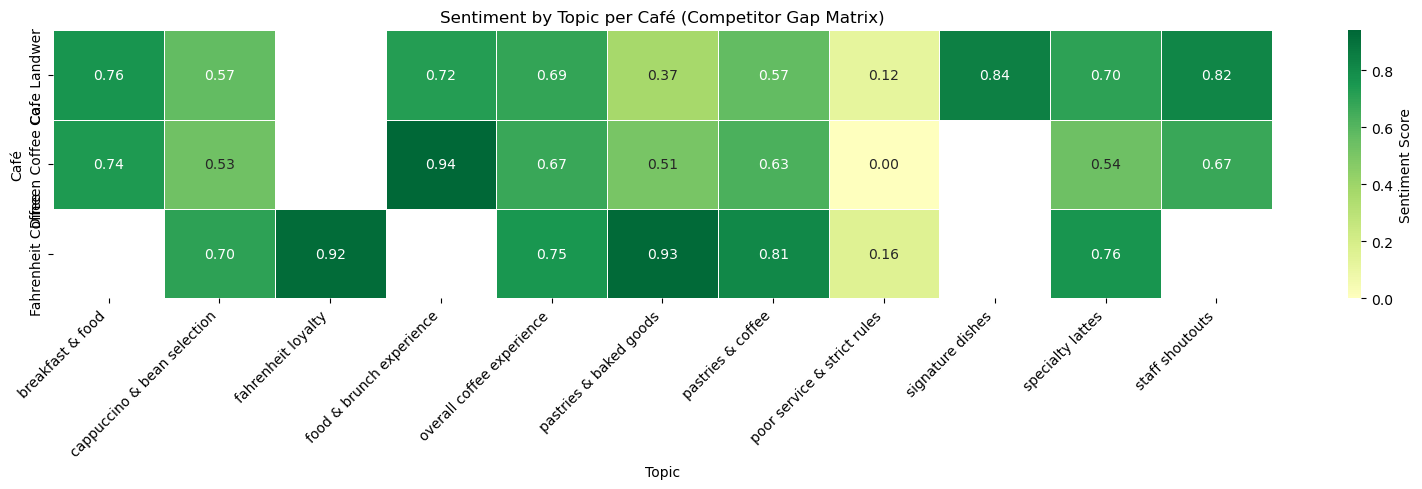

In [27]:
# ── 3. Competitor gap matrix ──────────────────────────────────────────────────
print("\n=== Average sentiment by topic per café (competitor gap matrix) ===")
pivot = (df_text[df_text['topic_id'] != -1]
         .groupby(['Restaurant Name', 'topic_label'])['sentiment_score']
         .mean()
         .unstack()
         .round(2))
print(pivot)

# Plot it as a heatmap
plt.figure(figsize=(16, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Sentiment Score'}
)
plt.title('Sentiment by Topic per Café (Competitor Gap Matrix)')
plt.xlabel('Topic')
plt.ylabel('Café')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('competitor_gap_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ── 4. Topic frequency per café ───────────────────────────────────────────────
print("\n=== Topic frequency per café (% of reviews) ===")
topic_freq = (df_text[df_text['topic_id'] != -1]
              .groupby(['Restaurant Name', 'topic_label'])
              .size()
              .unstack(fill_value=0))

# Convert to percentage of each café's total reviews
topic_freq_pct = topic_freq.div(topic_freq.sum(axis=1), axis=0).round(3) * 100
print(topic_freq_pct)


=== Topic frequency per café (% of reviews) ===
topic_label        breakfast & food  cappuccino & bean selection  \
Restaurant Name                                                    
Cafe Landwer                   11.3                          0.6   
Dineen Coffee Co.               0.3                          2.7   
Fahrenheit Coffee               0.0                          6.1   

topic_label        fahrenheit loyalty  food & brunch experience  \
Restaurant Name                                                   
Cafe Landwer                      0.0                      38.7   
Dineen Coffee Co.                 0.0                       0.3   
Fahrenheit Coffee                 4.4                       0.0   

topic_label        overall coffee experience  pastries & baked goods  \
Restaurant Name                                                        
Cafe Landwer                             9.0                     1.6   
Dineen Coffee Co.                       52.1              

In [29]:
# ── 5. What topics drive 5-star vs 1/2-star reviews ──────────────────────────
print("\n=== Topics most associated with 5-star reviews ===")
df_text['Rating'] = pd.to_numeric(df_text['Rating'], errors='coerce')
five_star = (df_text[df_text['Rating'] == 5]['topic_label']
             .value_counts(normalize=True) * 100).round(1)
low_star  = (df_text[df_text['Rating'] <= 2]['topic_label']
             .value_counts(normalize=True) * 100).round(1)

driver_df = pd.DataFrame({
    '5_star_%': five_star,
    '1_2_star_%': low_star
}).fillna(0)
driver_df['difference'] = (driver_df['5_star_%'] - driver_df['1_2_star_%']).round(1)
print(driver_df.sort_values('difference', ascending=False))


=== Topics most associated with 5-star reviews ===
                             5_star_%  1_2_star_%  difference
topic_label                                                  
overall coffee experience        35.2        11.4        23.8
food & brunch experience          7.7         2.4         5.3
staff shoutouts                   5.0         0.0         5.0
breakfast & food                  2.7         0.0         2.7
uncategorized                    38.7        36.5         2.2
signature dishes                  1.6         0.0         1.6
fahrenheit loyalty                1.4         0.0         1.4
cappuccino & bean selection       2.4         1.6         0.8
pastries & coffee                 1.0         0.4         0.6
specialty lattes                  2.4         3.1        -0.7
pastries & baked goods            1.1         2.7        -1.6
poor service & strict rules       0.8        42.0       -41.2



=== Rating trend over time per café ===
Cafe Landwer: improving (slope=0.0074, p=0.654)
Dineen Coffee Co.: declining (slope=-0.0068, p=0.185)
Fahrenheit Coffee: declining (slope=-0.0048, p=0.000)


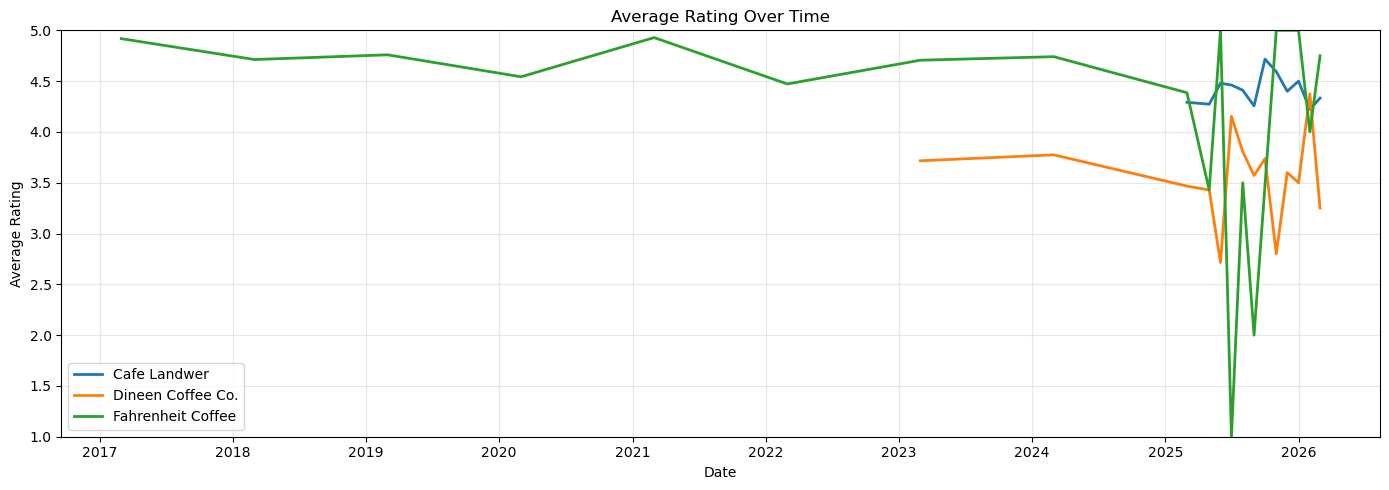

In [31]:
# ── 6. Rating trend over time ─────────────────────────────────────────────────
print("\n=== Rating trend over time per café ===")
df_text['Review Date'] = pd.to_datetime(df_text['Review Date'], errors='coerce')
df_text = df_text.dropna(subset=['Review Date'])
df_text = df_text.sort_values('Review Date')

for biz, group in df_text.groupby('Restaurant Name'):
    group = group.copy()
    group['month_num'] = (
        (group['Review Date'].dt.year - group['Review Date'].dt.year.min()) * 12 +
        group['Review Date'].dt.month
    )
    if len(group) < 10:
        continue
    slope, _, _, p, _ = stats.linregress(group['month_num'], group['Rating'])
    trend = 'improving' if slope > 0.001 else ('declining' if slope < -0.001 else 'stable')
    print(f"{biz}: {trend} (slope={slope:.4f}, p={p:.3f})")

# Plot rating over time
monthly_avg = (df_text.groupby(['Restaurant Name',
                df_text['Review Date'].dt.to_period('M')])['Rating']
               .mean()
               .reset_index())
monthly_avg['Review Date'] = monthly_avg['Review Date'].dt.to_timestamp()

plt.figure(figsize=(14, 5))
for biz in monthly_avg['Restaurant Name'].unique():
    subset = monthly_avg[monthly_avg['Restaurant Name'] == biz]
    plt.plot(subset['Review Date'], subset['Rating'], label=biz, linewidth=2)

plt.title('Average Rating Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.legend()
plt.ylim(1, 5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rating_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
df_text.tail()

,Review ID,Restaurant Name,Rating,Review Text,Review Date,Author Name,Owner Replied?,Owner Response,Response Date,Review Link,...,tag_order_type,tag_meal_type,tag_recommended_dishes,tag_parking,tag_wheelchair,sentiment_score,sentiment_label,topic_id,topic_prob,topic_label
1221,Ci9DQUlRQUNvZENodHljRjlvT2pKRWRFWjZNMjB5Y201MW...,Cafe Landwer,NaN,Ginormous portions and staff was so friendly. ...,2026-03-26,Nina K,No,NaN,NaN,https://www.google.com/maps/place/Cafe+Landwer...,...,NaN,brunch,NaN,NaN,NaN,0.8805,positive,10,0.469938,breakfast & food
592,Ci9DQUlRQUNvZENodHljRjlvT2tKWGN6bHJVVTFNT1ZVMF...,Dineen Coffee Co.,NaN,"I remember coming here back in early 2016, and...",2026-03-27,Elle Tremblay,No,NaN,NaN,https://www.google.com/maps/place/Dineen+Coffe...,...,NaN,NaN,NaN,NaN,NaN,-0.7430,negative,-1,0.000000,uncategorized
591,Ci9DQUlRQUNvZENodHljRjlvT2tkaU4zSXRiMUp1VUZaRF...,Dineen Coffee Co.,NaN,Nice place to treat yourself to a nice coffee ...,2026-03-27,Dave Barnes,No,NaN,NaN,https://www.google.com/maps/place/Dineen+Coffe...,...,NaN,brunch,NaN,NaN,NaN,0.8750,positive,5,0.593230,cozy but limited space
1220,Ci9DQUlRQUNvZENodHljRjlvT2xWT1VIVkRSMVZwV21SSW...,Cafe Landwer,NaN,"Pretty mid, overhyped for sure. Idk if we just...",2026-03-27,Luke Campbell (Luke),No,NaN,NaN,https://www.google.com/maps/place/Cafe+Landwer...,...,NaN,brunch,NaN,NaN,NaN,-0.3125,negative,-1,0.000000,uncategorized
1219,Ci9DQUlRQUNvZENodHljRjlvT2xOVWVFdzFObE0zYTAxVU...,Cafe Landwer,NaN,"The service is great, ELLAN is excellent!\nHig...",2026-03-28,A Chong,No,NaN,NaN,https://www.google.com/maps/place/Cafe+Landwer...,...,NaN,breakfast,NaN,NaN,NaN,0.8908,positive,3,0.712633,food & service praise


In [40]:
# Check what your date column actually looks like
print(df_text['Review Date'].dtype)
print(df_text['Review Date'].head(10))
print(f"Null dates: {df_text['Review Date'].isna().sum()}")

datetime64[ns]
539   2017-03-31
558   2017-03-31
557   2017-03-31
556   2017-03-31
555   2017-03-31
554   2017-03-31
553   2017-03-31
552   2017-03-31
550   2017-03-31
549   2017-03-31
Name: Review Date, dtype: datetime64[ns]
Null dates: 0


In [42]:
print(df_text['Review Date'].min())
print(df_text['Review Date'].max())

2017-03-31 00:00:00
2026-03-28 00:00:00


In [44]:
monthly_avg.head()

,Restaurant Name,Review Date,Rating
0,Cafe Landwer,2025-03-01,NaN
1,Cafe Landwer,2025-05-01,NaN
2,Cafe Landwer,2025-06-01,NaN
3,Cafe Landwer,2025-07-01,NaN
4,Cafe Landwer,2025-08-01,NaN


In [45]:
df_text.head()

,Review ID,Restaurant Name,Rating,Review Text,Review Date,Author Name,Owner Replied?,Owner Response,Response Date,Review Link,...,tag_order_type,tag_meal_type,tag_recommended_dishes,tag_parking,tag_wheelchair,sentiment_score,sentiment_label,topic_id,topic_prob,topic_label
539,ChZDSUhNMG9nS0VJQ0FnSUNRc015ZFRBEAE,Fahrenheit Coffee,NaN,Best Americano in Toronto. Minimal places to s...,2017-03-31,Hillary Johnstone,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,...,NaN,NaN,NaN,NaN,NaN,0.6369,positive,0,0.931223,city favourite
558,ChdDSUhNMG9nS0VJQ0FnSURnOThUaXpnRRAB,Fahrenheit Coffee,NaN,"I went to Fahrenheit today for the first time,...",2017-03-31,Bilal El Houri,Yes,Glad to hear it Bilal! See you soon!,NaN,https://www.google.com/maps/place/Fahrenheit+C...,...,NaN,NaN,NaN,NaN,NaN,0.9423,positive,19,1.000000,fahrenheit loyalty
557,ChZDSUhNMG9nS0VJQ0FnSURRbzY3Q0R3EAE,Fahrenheit Coffee,NaN,Little hidden gem of Toronto. You will get one...,2017-03-31,Sleiman-Tanios Chahwan,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,...,NaN,NaN,NaN,NaN,NaN,0.6369,positive,0,1.000000,city favourite
556,ChdDSUhNMG9nS0VJQ0FnSURBc1o3MzVBRRAB,Fahrenheit Coffee,NaN,"Great coffee, friendly, knowledgeable and ener...",2017-03-31,Diana Lai,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,...,NaN,NaN,NaN,NaN,NaN,0.8807,positive,4,0.928704,friendly staff & food
555,ChZDSUhNMG9nS0VJQ0FnSURBNGJfUFJREAE,Fahrenheit Coffee,NaN,Great coffee. Friendly staff.,2017-03-31,Raffi Ghazarian,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,...,NaN,NaN,NaN,NaN,NaN,0.8074,positive,4,1.000000,friendly staff & food


In [46]:
df.head()

,Review ID,Restaurant Name,Rating,Review Text,Review Date,Author Name,Owner Replied?,Owner Response,Response Date,Review Link,...,tag_service_rating,tag_atmosphere_rating,tag_price_per_person,tag_order_type,tag_meal_type,tag_recommended_dishes,tag_parking,tag_wheelchair,sentiment_score,sentiment_label
0,ChdDSUhNMG9nS0VJQ0FnSUNCZ3NIYmpBRRAB,Fahrenheit Coffee,4 ★★★★☆,Very high quality coffee that makes you think ...,2026-03-25,Omar Saeed,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,...,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,-0.4588,negative
1,Ci9DQUlRQUNvZENodHljRjlvT21oNVIxRnNVelZYTVZFdG...,Fahrenheit Coffee,5 ★★★★★,Lovely vanilla lattes!\nOrder type\nTake out\n...,2026-03-25,Phoebe Ting,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,...,4.0,NaN,1–10,NaN,NaN,NaN,NaN,NaN,NaN,None
2,Ci9DQUlRQUNvZENodHljRjlvT25KU1dWaGhhakIzYWxSWV...,Fahrenheit Coffee,5 ★★★★★,"I ordered Ethiopia coffee, and its taste is ve...",2026-03-22,Jeongmin Lee,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,...,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,0.8126,positive
3,Ci9DQUlRQUNvZENodHljRjlvT210T1ZYVmxOMVI1WTFwME...,Fahrenheit Coffee,5 ★★★★★,Amazing Latte! definitely recommend checking i...,2026-03-15,Jaskaran Singh,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,...,5.0,5.0,NaN,dine in,NaN,NaN,NaN,NaN,0.9201,positive
4,Ci9DQUlRQUNvZENodHljRjlvT21Nd2NETmxOMlkxZWtScF...,Fahrenheit Coffee,5 ★★★★★,"Sameer was amazing, wonderful service. I came ...",2026-03-15,Simone Jehayem,No,NaN,NaN,https://www.google.com/maps/place/Fahrenheit+C...,...,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,0.9566,positive


In [47]:
print(df['Rating'].dtype)

object
